# EDA 2 — Post-extraction analysis

Everything here comes from **our pipeline**: 1,000 German notes → DeepSeek → strict Pydantic schema → deterministic repair rules. Ground truth appears only in the "reliability" section (scoring), never as an analysis source.

Convention: **blue = corpus/service, orange = damage**, gradient = ordinal. German terms are translated for reading (see the glossary in `First EDA.ipynb`); verbatim German is kept only where it IS the data (note wording patterns).

In [1]:
import sys, json, collections
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PIPE = Path(r"C:\Users\benda\Desktop\Hackathon\Work\pipeline")
sys.path.insert(0, str(PIPE))
from extract import load_cases, read_cached
from lexicon import FEW_SHOT_IDS, zone_string
from run_pilot import pick_pilot_ids
from repair_logic import derive_operations

BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#6b6b66"
SEQ_ORANGE = ["#f6c3ad", "#f0925f", "#eb6834"]
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e6e3", "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
})
def bar_labels(ax):
    for c in ax.containers: ax.bar_label(c, padding=2, fontsize=9, color="#4a4a46")

EN_KIND = {"Parkschaden": "Parking damage", "Rangierschaden": "Maneuvering damage",
    "Auffahrunfall": "Rear-end collision", "Hagelschaden": "Hail damage", "Steinschlag": "Stone chip",
    "Vandalismus": "Vandalism", "Wildunfall": "Wildlife collision", "Inspektion": "Inspection",
    "Ölwechsel": "Oil change", "HU/AU": "Roadworthiness test", "Räder und Reifen": "Wheels & tyres",
    "Bremsen": "Brakes", "unklar": "unclear"}
EN_SEV = {"leicht": "light", "mittel": "medium", "schwer": "severe"}
EN_INS = {"teilkasko": "partial cover (TK)", "vollkasko": "full compr. (VK)",
    "haftpflicht_gegner": "other party's liability", "selbstzahler": "self-payer",
    "gesteuert": "steered claim", "unbekannt": "unknown"}
EN_PART = {"stossfaenger_vorne": "front bumper", "stossfaenger_hinten": "rear bumper",
    "motorhaube": "bonnet", "kotfluegel_vorne": "front fender", "kotfluegel_hinten": "rear quarter panel",
    "tuer_vorne": "front door", "tuer_hinten": "rear door", "schweller": "sill", "aussenspiegel": "mirror",
    "dach": "roof", "heckklappe": "tailgate", "windschutzscheibe": "windscreen",
    "sonstiges_karosserie": "other (body)", "scheinwerfer": "headlight", "rueckleuchte": "taillight",
    "kuehlergrill": "grille", "zierleiste_anbauteil": "trim/attachment", "seitenscheibe": "side window",
    "tuerverkleidung": "door panel"}
EN_ZONE_WORDS = {"Stoßstange": "bumper", "Kotflügel": "fender", "Fahrertür": "driver door",
    "Beifahrertür": "passenger door", "Tür": "door", "Schweller": "sill", "Außenspiegel": "mirror",
    "Motorhaube": "bonnet", "Heckklappe": "tailgate", "Dach": "roof", "Windschutzscheibe": "windscreen",
    "vorne": "front", "hinten": "rear", "links": "left", "rechts": "right"}
def zone_en(z):
    w = [EN_ZONE_WORDS.get(x, x) for x in z.split()]
    if len(w) > 1 and w[1] in ("front", "rear"): w[0], w[1] = w[1], w[0]
    return " ".join(w)

cases = load_cases()
records = {cid: read_cached(cid) for cid in cases}
records = {k: v for k, v in records.items() if v is not None}
rows = []
for cid, r in records.items():
    ex = r.extraction
    sev = ex.overall_severity
    rows.append({
        "id": cid, "kind": ex.case_kind.value, "type": ex.case_type,
        "severity": sev.value if sev else None,
        "insurance": ex.versicherung.typ.value, "sb": ex.versicherung.sb_betrag_eur,
        "n_schaeden": len(ex.schaeden),
        "zones": [z for s in ex.schaeden if (z := zone_string(s.part, s.seite))],
        "n_neben": len(ex.nebenbefunde), "open": cases[cid]["in_open_list"],
        "created": cases[cid]["created_at"],
    })
df = pd.DataFrame(rows)
print(f"{len(df)} extracted cases — {df['type'].value_counts().to_dict()}")

1000 extracted cases — {'service': 550, 'damage': 450}


## Reliability — the official numbers (977-case test split, never seen during tuning)

In [2]:
rep = json.loads((PIPE / "eval_report.json").read_text(encoding="utf-8"))
tab = pd.DataFrame({
    "DeepSeek": rep["deepseek"]["test"], "Regex baseline": rep["baseline"]["test"],
}).loc[["kind_acc", "zones_precision", "zones_recall", "zones_f1", "severity_acc", "insurance_acc"]]
tab.index = ["case kind accuracy", "zones precision", "zones recall", "zones F1", "severity accuracy", "insurance accuracy"]
tab = (tab * 100).round(1)
print(f"Tokens: {rep['prompt_tokens']+rep['completion_tokens']:,} · Wall time: {rep['wall_seconds']/60:.1f} min · "
      f"Evidence quotes verbatim: {rep['quote_verbatim_rate']*100:.1f}% · flagged: {len(rep['flagged_cases'])}")
print("Out-of-vocabulary terms:", rep["unmapped_terms"], "(Bremsscheiben = brake discs, Aufnahme = mounting/intake)")
tab

Tokens: 2,676,091 · Wall time: 10.8 min · Evidence quotes verbatim: 100.0% · flagged: 0
Out-of-vocabulary terms: {'Bremsscheiben': 3, 'Aufnahme': 2} (Bremsscheiben = brake discs, Aufnahme = mounting/intake)


,DeepSeek,Regex baseline
case kind accuracy,100.0,99.2
zones precision,100.0,100.0
zones recall,99.9,100.0
zones F1,99.9,100.0
severity accuracy,68.7,0.0
insurance accuracy,100.0,76.0


## The assumed weak link: severity (68.7%) — and why it is close to the ceiling

Severity is never written. We infer it from wording — but the generator only **partially** coupled it to the text. Proof: we fingerprint the damage descriptors of every note and check whether the same fingerprint always yields the same GT severity.

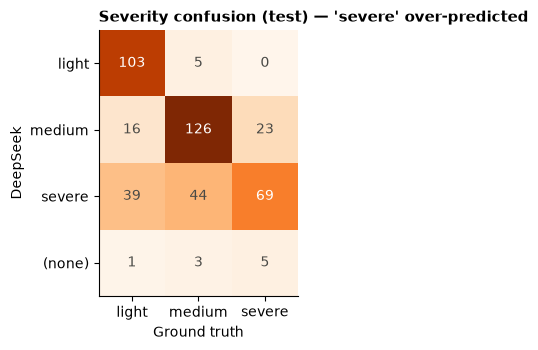

Theoretical ceiling (perfect wording->majority-class lookup): 79.5%
Cases with NO textual cue at all: 61 — split {'schwer': 21, 'mittel': 15, 'leicht': 25} => pure noise
Our 68.7% therefore captures ~86% of the extractable signal.
Most ambiguous wording (German pattern = the data): 'eingedrückt' (pressed in) -> sometimes medium, sometimes severe;
'Reparatur laut Prüfung möglich' (repair possible per inspection) -> found under all three severities.


In [3]:
dev = set(pick_pilot_ids(cases)) | set(FEW_SHOT_IDS)
test_ids = [cid for cid in cases if cid not in dev and cases[cid]["ground_truth"]["severity"] and cid in records]

order = ["leicht", "mittel", "schwer"]
order_en = ["light", "medium", "severe"]
conf = np.zeros((4, 3), dtype=int)
for cid in test_ids:
    sev = records[cid].extraction.overall_severity
    p = order.index(sev.value) if sev else 3
    g = order.index(cases[cid]["ground_truth"]["severity"])
    conf[p, g] += 1
fig, ax = plt.subplots(figsize=(4.6, 3.6))
im = ax.imshow(conf, cmap="Oranges")
ax.set_xticks(range(3), order_en); ax.set_yticks(range(4), order_en + ["(none)"])
ax.set_xlabel("Ground truth"); ax.set_ylabel("DeepSeek"); ax.grid(False)
for i in range(4):
    for j in range(3):
        ax.text(j, i, conf[i, j], ha="center", va="center",
                color="white" if conf[i, j] > conf.max() * .5 else "#4a4a46")
ax.set_title("Severity confusion (test) — 'severe' over-predicted")
plt.tight_layout(); plt.show()

PATS = ['Kratzer im Klarlack','feine Kratzspuren','Schrammen','Druckstelle','kleine Delle','Lack laut Sichtprüfung intakt',
        'eingedrückt','Delle mit Lackschaden','Riss im Lack','Lack abgeplatzt','bis auf Grundierung','Halterung gebrochen',
        'Träger verformt','gerissen und lose','großflächig','zahlreichen Dellen','flächig','mehreren Dellen','Dellenkarte',
        'Riss wird','Harzreparatur','außerhalb Sichtfeld','im Sichtfeld','Austausch nötig','Reparatur laut Prüfung möglich','punktuell']
fp = collections.defaultdict(collections.Counter)
for cid in test_ids:
    body = cases[cid]["freitext"].split("~~~")[0]
    fp[tuple(sorted(p for p in PATS if p in body))][cases[cid]["ground_truth"]["severity"]] += 1
ceiling = sum(max(c.values()) for c in fp.values()) / len(test_ids)
no_cue = fp.get((), collections.Counter())
print(f"Theoretical ceiling (perfect wording->majority-class lookup): {ceiling*100:.1f}%")
print(f"Cases with NO textual cue at all: {sum(no_cue.values())} — split {dict(no_cue)} => pure noise")
print(f"Our 68.7% therefore captures ~{68.7/(ceiling*100)*100:.0f}% of the extractable signal.")
print("Most ambiguous wording (German pattern = the data): 'eingedrückt' (pressed in) -> sometimes medium, sometimes severe;")
print("'Reparatur laut Prüfung möglich' (repair possible per inspection) -> found under all three severities.")

## Visual insight #1: the zone × case-kind signature
Each accident kind "signs" different zones — computed from our extractions; this is what the dashboard's car heatmap summarizes.

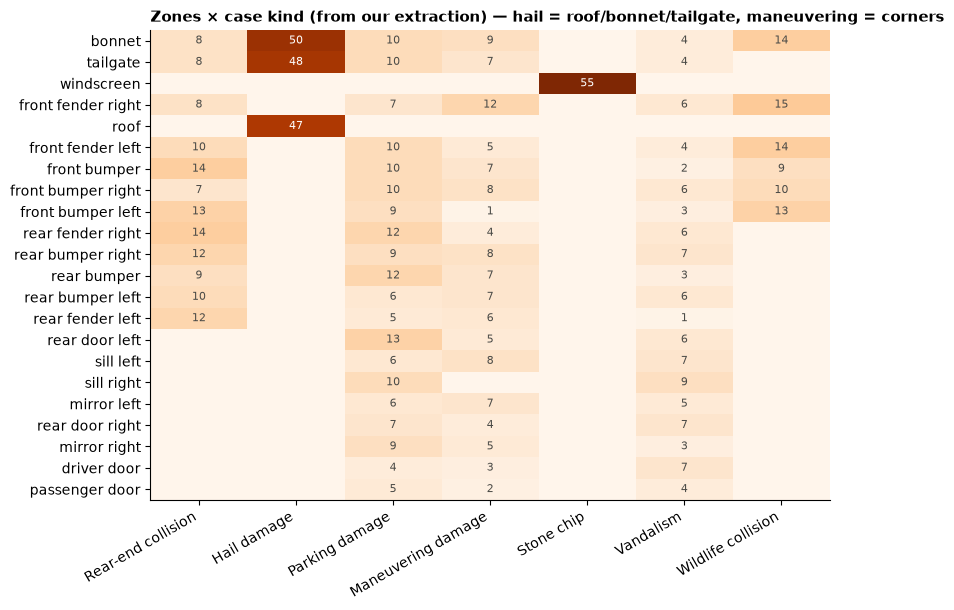

In [4]:
dmg = df[df["type"] == "damage"].explode("zones").dropna(subset=["zones"])
pv = dmg.pivot_table(index="zones", columns="kind", aggfunc="size", fill_value=0)
pv = pv.loc[pv.sum(axis=1).sort_values(ascending=False).index]
pv.index = [zone_en(z) for z in pv.index]
pv.columns = [EN_KIND.get(k, k) for k in pv.columns]
fig, ax = plt.subplots(figsize=(8.5, 6.2))
im = ax.imshow(pv.values, cmap="Oranges", aspect="auto")
ax.set_xticks(range(len(pv.columns)), pv.columns, rotation=30, ha="right")
ax.set_yticks(range(len(pv.index)), pv.index); ax.grid(False)
for i in range(pv.shape[0]):
    for j in range(pv.shape[1]):
        v = pv.values[i, j]
        if v: ax.text(j, i, v, ha="center", va="center", fontsize=8,
                      color="white" if v > pv.values.max() * .55 else "#4a4a46")
ax.set_title("Zones × case kind (from our extraction) — hail = roof/bonnet/tailgate, maneuvering = corners")
plt.tight_layout(); plt.show()

## What the workshop must order and take off (deterministic rules)

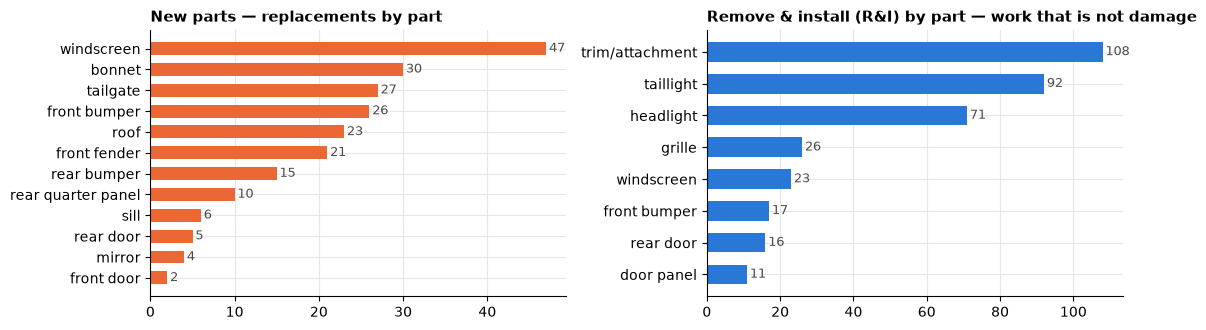

216 replacement operations induce 389 R&I operations across 450 damage cases


In [5]:
ops = collections.Counter(); ri = collections.Counter()
for cid, r in records.items():
    for o in derive_operations(r.extraction):
        if o.op.value == "ersetzen": ops[EN_PART[o.part.value]] += 1
        if o.op.value == "aus_einbau": ri[EN_PART[o.part.value]] += 1
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
s1 = pd.Series(ops).sort_values()
axes[0].barh(s1.index, s1.values, color=ORANGE, height=.62); bar_labels(axes[0])
axes[0].set_title("New parts — replacements by part")
s2 = pd.Series(ri).sort_values().tail(8)
axes[1].barh(s2.index, s2.values, color=BLUE, height=.62); bar_labels(axes[1])
axes[1].set_title("Remove & install (R&I) by part — work that is not damage")
plt.tight_layout(); plt.show()
print(f"{sum(ops.values())} replacement operations induce {sum(ri.values())} R&I operations across 450 damage cases")

## Who pays what — severity × payer, and the deductibles (SB)

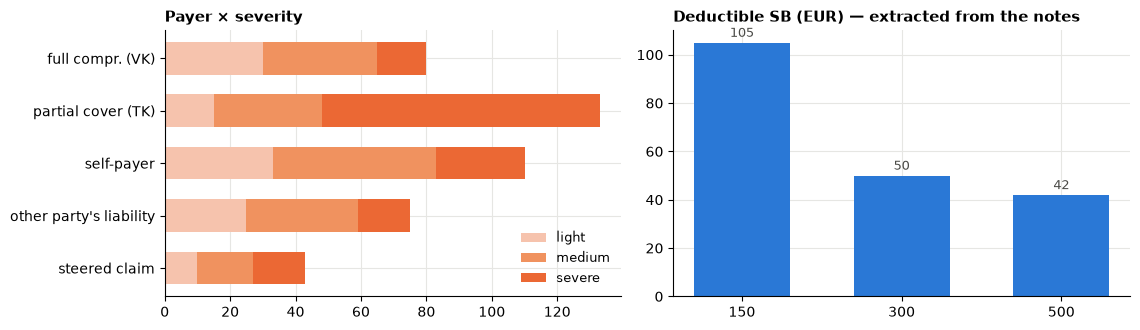

In [6]:
d = df[df["type"] == "damage"].copy()
ct = pd.crosstab(d["insurance"], d["severity"])[["leicht", "mittel", "schwer"]]
ct.index = [EN_INS.get(i, i) for i in ct.index]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
bottom = np.zeros(len(ct))
for i, sev in enumerate(["leicht", "mittel", "schwer"]):
    axes[0].barh(ct.index, ct[sev], left=bottom, color=SEQ_ORANGE[i], label=EN_SEV[sev], height=.62)
    bottom += ct[sev].values
axes[0].legend(frameon=False, fontsize=9); axes[0].set_title("Payer × severity")
sb = d["sb"].dropna().astype(int).value_counts().sort_index()
axes[1].bar(sb.index.astype(str), sb.values, color=BLUE, width=.6); bar_labels(axes[1])
axes[1].set_title("Deductible SB (EUR) — extracted from the notes")
plt.tight_layout(); plt.show()

## Operational backlog — open cases age differently per kind

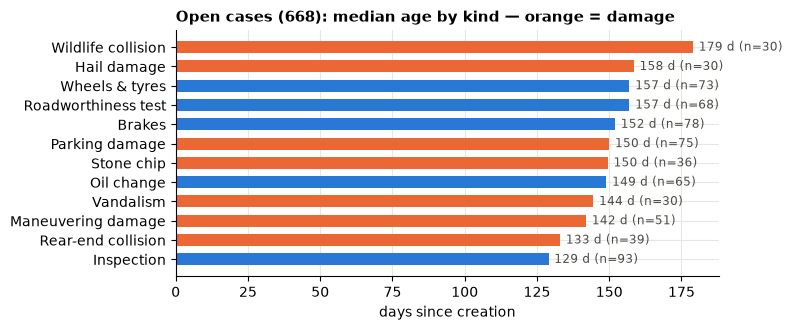

In [7]:
df["age_days"] = (pd.Timestamp("2026-09-18") - pd.to_datetime(df["created"])).dt.days
op = df[df["open"]]
agg = op.groupby("kind")["age_days"].agg(["count", "median"]).sort_values("median", ascending=False)
DAMAGE = {"Parkschaden","Rangierschaden","Auffahrunfall","Hagelschaden","Steinschlag","Vandalismus","Wildunfall"}
colors = [ORANGE if k in DAMAGE else BLUE for k in agg.index]
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.barh([EN_KIND.get(k, k) for k in agg.index[::-1]], agg["median"][::-1], color=colors[::-1], height=.62)
for y, (m, n) in enumerate(zip(agg["median"][::-1], agg["count"][::-1])):
    ax.text(m + 2, y, f"{m:.0f} d (n={n})", va="center", fontsize=8.5, color="#4a4a46")
ax.set_title(f"Open cases ({len(op)}): median age by kind — orange = damage")
ax.set_xlabel("days since creation")
plt.tight_layout(); plt.show()

## Takeaways (fireside)

1. **99.9% zones F1, 100% case kind / insurance, 100% verbatim evidence quotes, 0 cases lost** on 977 unseen test cases — the extraction is industrial-grade (per-case cache, backoff, 11 min / 2.7M tokens for the corpus).
2. **Severity 68.7% ≈ 86% of the ~79.5% ceiling**: the generator partially decorrelates severity from wording (61 cases carry no cue). We PROVE the ceiling instead of suffering it.
3. **The regex baseline scores 100% on zones** (closed vocabulary, verbatim) **but 0% on severity and 76% on insurance** — the LLM wins exactly where the text requires understanding, and would win on zones too on real-world, non-templated notes.
4. Workshop insights: hail signature (roof+bonnet+tailgate co-occur), front corners = maneuvering/parking, **massive R&I induced by replacements** (trim 108×, taillights 92×, headlights 71×), open backlog median ~150 days, upsell potential in secondary findings (cabin filter, rattling, ...).
5. Where it breaks: only 2 out-of-vocabulary terms in the whole corpus ("Bremsscheiben" = brake discs ×3, "Aufnahme" = mounting ×2 — flagged, never dropped), 1 missed zone out of 752.